## Worksheet 5 -- Bayesian Regression

### Task 1

In [12]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

In [13]:
df = pd.read_csv('data.csv', on_bad_lines='skip', header=13)
cleaned = df.dropna()

print("The new dataset has {} planets. Down from the original {}.".format(len(cleaned), len(df)))

The new dataset has 2914 planets. Down from the original 39803.


In [ ]:
# Same selection that was done for worksheet 4 with reshaping for sklearn.
x = np.log10(cleaned['pl_rade'].values).reshape(-1, 1)
y = np.log10(cleaned['pl_masse'].values)

mass_err = 0.5 * (np.abs(cleaned['pl_masseerr1']) + np.abs(cleaned['pl_masseerr2']))
y_err = (mass_err / (cleaned['pl_masse'] * np.log(10))).values

alpha = np.maximum(y_err**2, 0.3**2)  # variance, not standard deviation

In [ ]:
# Define the kernel, with sigma_f^2 and length_scale as hyperparameters to be optimised.
# ConstantKernel handles sigma_f^2, RBF handles the exponential part
kernel_single = ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3)) \
              * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

gp_single = GaussianProcessRegressor(
    kernel=kernel_single,
    alpha=alpha,          # per-point noise variance (sigma_n^2)
    n_restarts_optimizer=30, # restart the hyperparameter optimiser to avoid local minima
    normalize_y=True         # subtract mean of y before fitting 
)

gp_single.fit(x, y)

print("Optimised kernel:", gp_single.kernel_)
print("Log-marginal-likelihood:", gp_single.log_marginal_likelihood_value_)

# Predict on a fine grid
x_pred = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)

y_pred, y_std = gp_single.predict(x_pred, return_std=True)


Optimised kernel: 1.2**2 * RBF(length_scale=0.17)
Log-marginal-likelihood: -1942.5912234113434


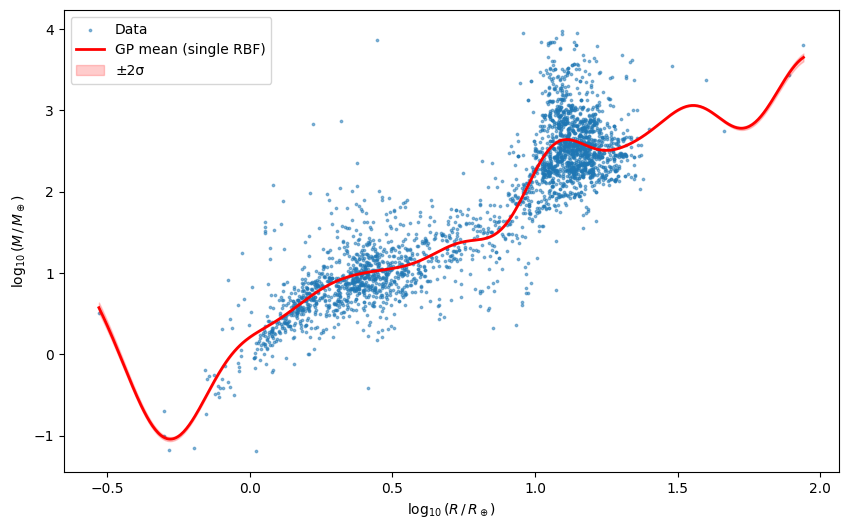

In [23]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=3, alpha=0.5, label='Data')
plt.plot(x_pred, y_pred, 'r-', lw=2, label='GP mean (single RBF)')
plt.fill_between(x_pred.ravel(),
                 y_pred - 2*y_std,
                 y_pred + 2*y_std,
                 alpha=0.2, color='red', label='±2σ')
plt.xlabel(r'$\log_{10}(R\,/\,R_\oplus)$')
plt.ylabel(r'$\log_{10}(M\,/\,M_\oplus)$')
plt.legend()
#plt.title('Single RBF Kernel GP')
plt.show()

### Task 2

In [ ]:
# Set the parameters for the three RBF kernels to cover a range of length scales.
kernel_combined = (
    ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-2, 1e1))
  + ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
  + ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=2.0, length_scale_bounds=(1e-1, 1e3))
)

gp_combined = GaussianProcessRegressor(
    kernel=kernel_combined,
    alpha=alpha,
    n_restarts_optimizer=30,  # more restarts — bigger hyperparameter space now
    normalize_y=True
)

gp_combined.fit(x, y)

print("Optimised kernel:", gp_combined.kernel_)
print("Log-marginal-likelihood:", gp_combined.log_marginal_likelihood_value_)

y_pred_comb, y_std_comb = gp_combined.predict(x_pred, return_std=True)

/home/kali/Documents/Uni/SS2026/DataScience/DataScience/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Optimised kernel: 0.0745**2 * RBF(length_scale=0.01) + 1.99**2 * RBF(length_scale=1.47) + 0.413**2 * RBF(length_scale=0.153)
Log-marginal-likelihood: -1913.6296765752886


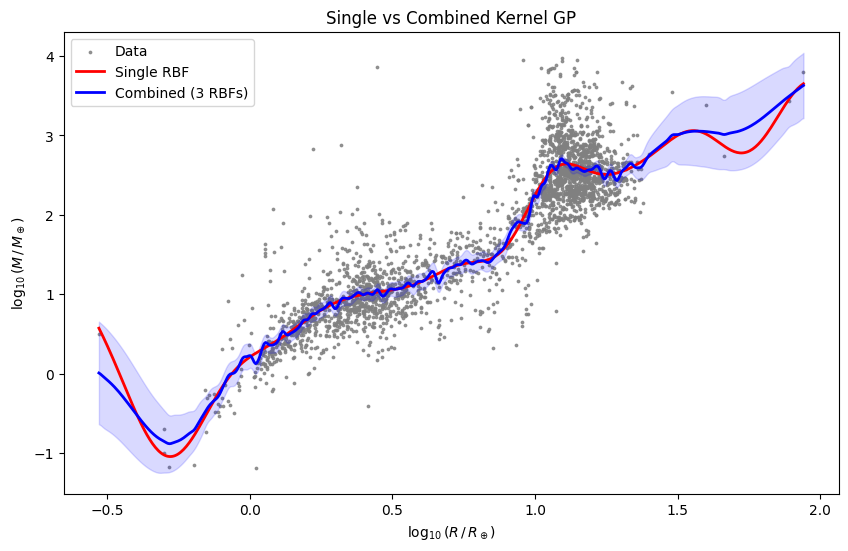

In [20]:
# Plot both models together
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=3, alpha=0.8, label='Data', color='grey')
plt.plot(x_pred, y_pred, 'r-', lw=2, label='Single RBF')
plt.plot(x_pred, y_pred_comb, 'b-', lw=2, label='Combined (3 RBFs)')
plt.fill_between(x_pred.ravel(),
                 y_pred_comb - 2*y_std_comb,
                 y_pred_comb + 2*y_std_comb,
                 alpha=0.15, color='blue')
plt.xlabel(r'$\log_{10}(R\,/\,R_\oplus)$')
plt.ylabel(r'$\log_{10}(M\,/\,M_\oplus)$')
plt.legend()
plt.title('Single vs Combined Kernel GP')
plt.show()

In [21]:
EARTH_RADIUS_KM = 6378.13
EARTH_MASS = 5.972  # in units of 1e24 kg (= 1 Earth mass)

solar_system = {
    'Mercury': {'R_km': 2439.4, 'M_true': 0.330103},
    'Venus':   {'R_km': 6051.8, 'M_true': 4.86731},
    'Earth':   {'R_km': 6371.0084, 'M_true': 5.972},
    'Mars':    {'R_km': 3389.50, 'M_true': 0.641691},
    'Jupiter': {'R_km': 69911,  'M_true': 1898.125},
    'Saturn':  {'R_km': 58232,  'M_true': 568.317},
    'Uranus':  {'R_km': 25362,  'M_true': 86.8099},
    'Neptune': {'R_km': 24622,  'M_true': 102.4092},
}

def predict_solar_system(predict_fn):
    """Predict and compare mass for solar system planets."""
    for name, data in solar_system.items():
        R_earth = data['R_km'] / EARTH_RADIUS_KM
        log_R = np.log10(R_earth)
        log_M_pred = predict_fn(log_R)
        M_pred = 10**log_M_pred
        M_actual = data['M_true'] / EARTH_MASS
        print(f"{name:8s}: predicted = {M_pred:.3f}, actual = {M_actual:.3f}")

In [22]:
print("=== Single RBF Kernel ===")
predict_solar_system(
    lambda log_R: gp_single.predict(np.array([[log_R]]))[0]
)

print()

print("=== Combined Kernel (3 RBFs) ===")
predict_solar_system(
    lambda log_R: gp_combined.predict(np.array([[log_R]]))[0]
)

=== Single RBF Kernel ===
Mercury : predicted = 0.464, actual = 0.055
Venus   : predicted = 1.399, actual = 0.815
Earth   : predicted = 1.613, actual = 1.000
Mars    : predicted = 0.091, actual = 0.107
Jupiter : predicted = 302.218, actual = 317.837
Saturn  : predicted = 93.551, actual = 95.164
Uranus  : predicted = 14.336, actual = 14.536
Neptune : predicted = 13.735, actual = 17.148

=== Combined Kernel (3 RBFs) ===
Mercury : predicted = 0.385, actual = 0.055
Venus   : predicted = 1.596, actual = 0.815
Earth   : predicted = 1.692, actual = 1.000
Mars    : predicted = 0.132, actual = 0.107
Jupiter : predicted = 287.564, actual = 317.837
Saturn  : predicted = 78.329, actual = 95.164
Uranus  : predicted = 14.487, actual = 14.536
Neptune : predicted = 14.184, actual = 17.148
